<a href="https://colab.research.google.com/github/sohelarfi0/Customer_Churn_Predictions/blob/main/Customer_Churn_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Customer Churn Prediction**

In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

#Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

#Matrics & utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,roc_auc_score,confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")

# Display settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
pd.set_option('display.max_columns',200)



**Loading the data**






In [3]:
df = pd.read_csv('/content/sample_data/Bank Customer Churn Prediction.csv')
print("Shape: ", df.shape)
df.head()

Shape:  (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Info & Summary
display(df.info())
display(df.describe(include='all').T)

# Missing Values
print("\n Missing values per column: ")
print(df.isnull().sum)

#Target distribution
print("\n Churn value counts: ")
print(df['churn'].value_counts(normalize=False))
print("\n Churn properties:")
print(df['churn'].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0



 Missing values per column: 
<bound method DataFrame.sum of       customer_id  credit_score  country  gender    age  tenure  balance  \
0           False         False    False   False  False   False    False   
1           False         False    False   False  False   False    False   
2           False         False    False   False  False   False    False   
3           False         False    False   False  False   False    False   
4           False         False    False   False  False   False    False   
...           ...           ...      ...     ...    ...     ...      ...   
9995        False         False    False   False  False   False    False   
9996        False         False    False   False  False   False    False   
9997        False         False    False   False  False   False    False   
9998        False         False    False   False  False   False    False   
9999        False         False    False   False  False   False    False   

      products_number  cre

**Exploratory Data Analysis(Visualisation)**

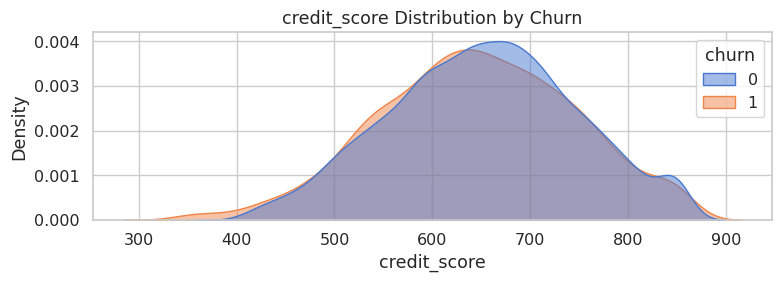

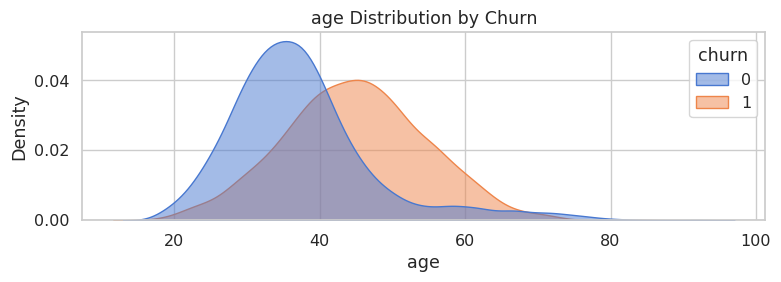

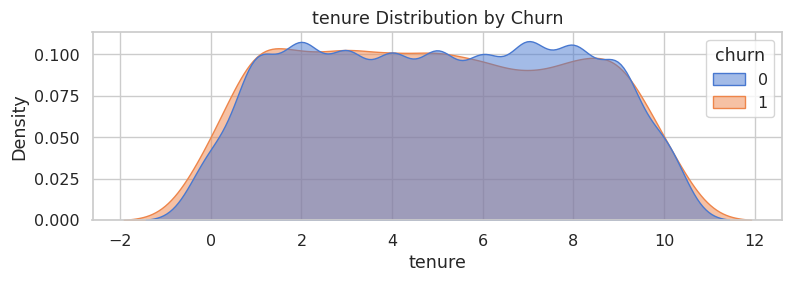

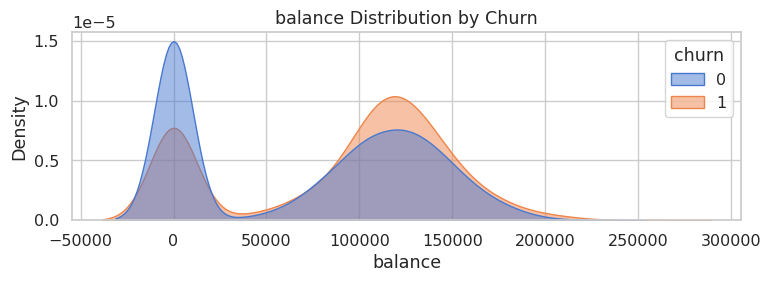

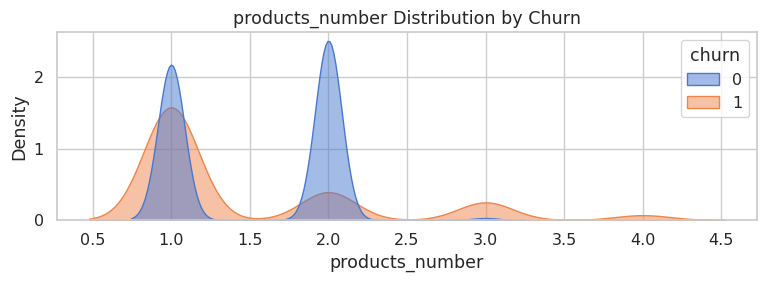

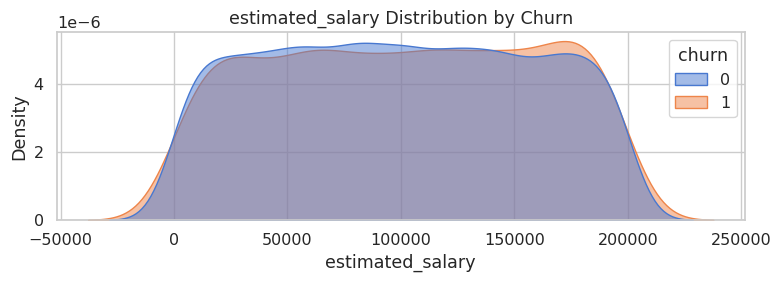

In [5]:
num_cols =['credit_score', 'age', 'tenure', 'balance', 'products_number','estimated_salary']

# Distribution
for col in num_cols:
           plt.figure(figsize=(8,3))
           sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, alpha=0.5)
           plt.title(f'{col} Distribution by Churn')
           plt.tight_layout()
           plt.show()

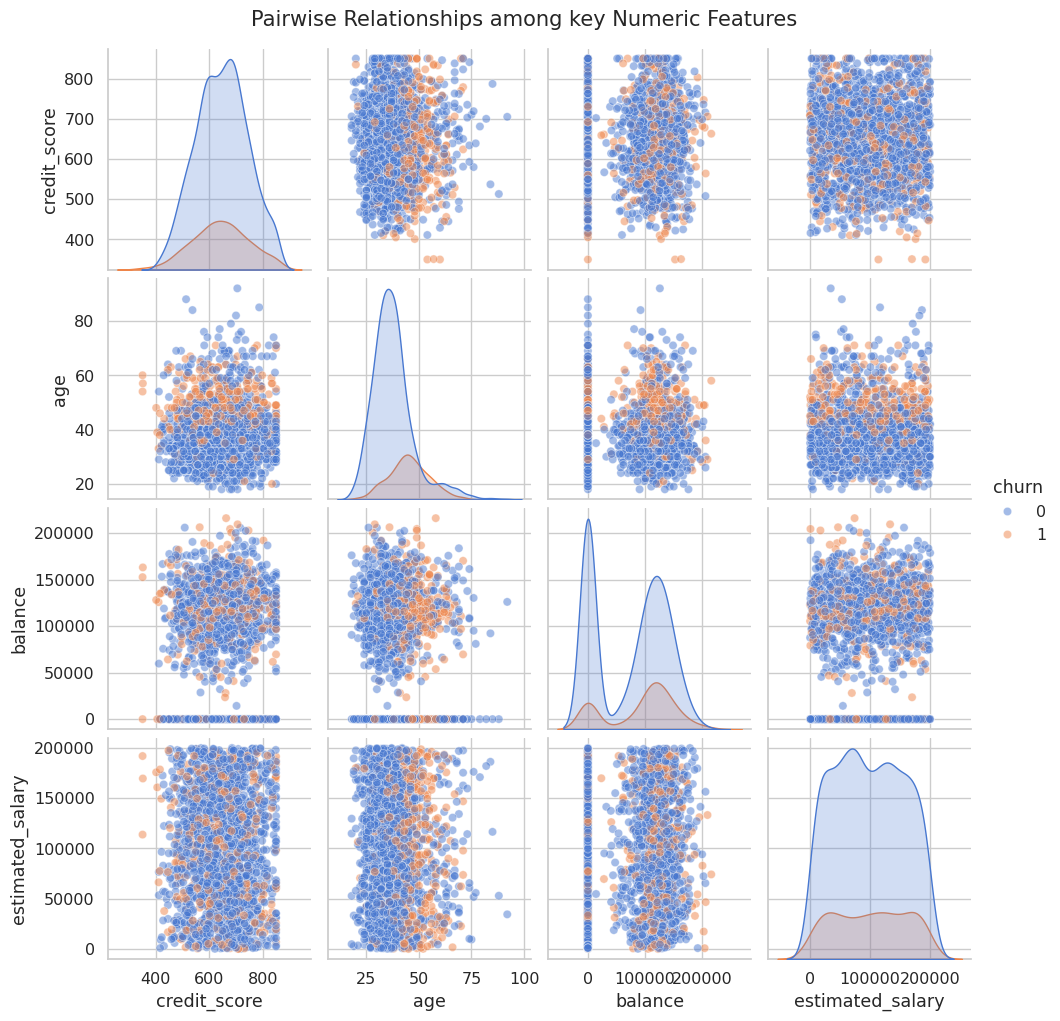

In [6]:
# pairplot (sample for speed)
sns.pairplot(df.sample(frac=0.2, random_state=42),
             vars=['credit_score','age','balance', 'estimated_salary'],
             hue='churn', diag_kind= 'kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairwise Relationships among key Numeric Features', y=1.02)
plt.show()

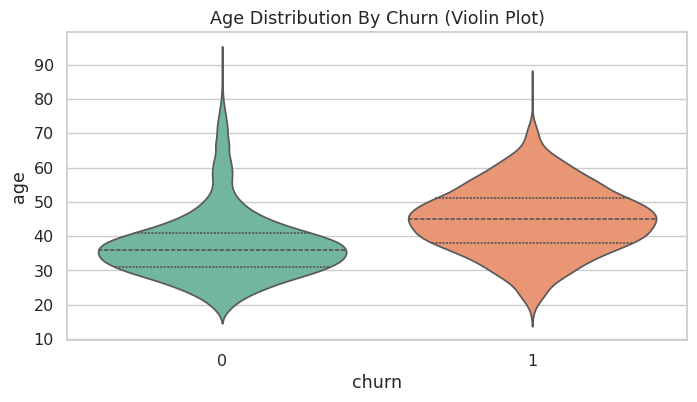

In [7]:
# violin plot for Age
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='churn',y='age',inner='quart',palette='Set2')
plt.title('Age Distribution By Churn (Violin Plot)')
plt.show()

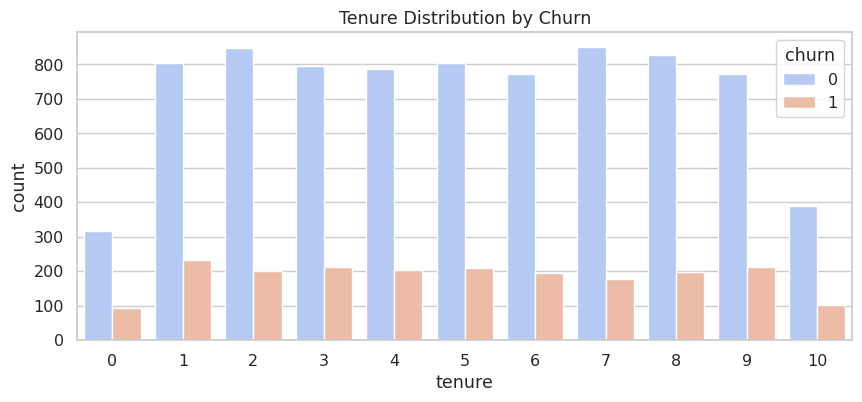

In [8]:
# Tenure distribution
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='tenure', hue='churn',palette='coolwarm')
plt.title('Tenure Distribution by Churn')
plt.show()

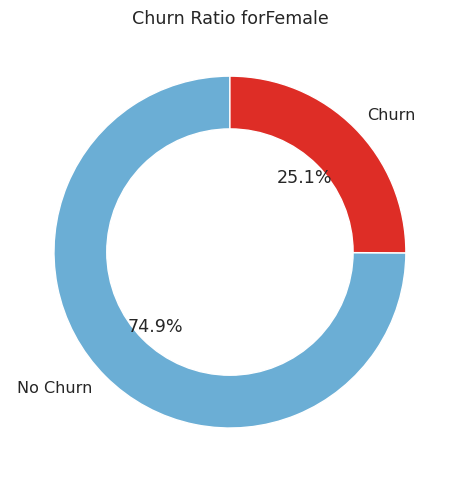

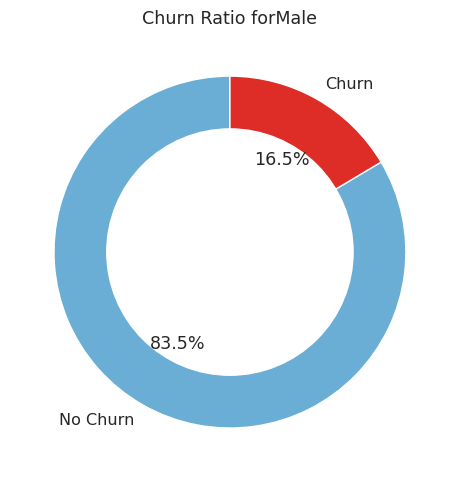

In [9]:
# Gender vs Churn Donut Chart
gender_counts = df.groupby('gender')['churn'].value_counts(normalize=True).unstack().fillna(0)
for gender in gender_counts.index:
  plt.figure(figsize=(5,5))
  plt.pie(gender_counts.loc[gender],labels=['No Churn', 'Churn'],
          autopct='%1.1f%%', startangle=90, colors=['#6baed5', '#de2d26'])
  center=plt.Circle((0,0),0.70, fc='white')
  fig=plt.gcf()
  fig.gca().add_artist(center)
  plt.title(f'Churn Ratio for{gender}')
  plt.tight_layout()
  plt.show()


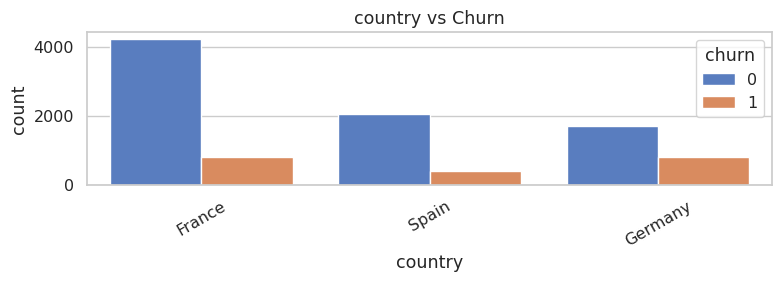

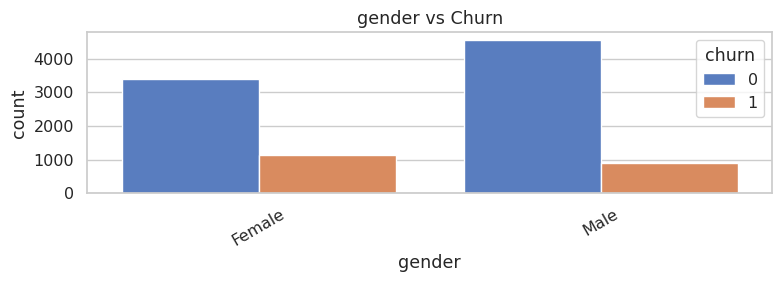

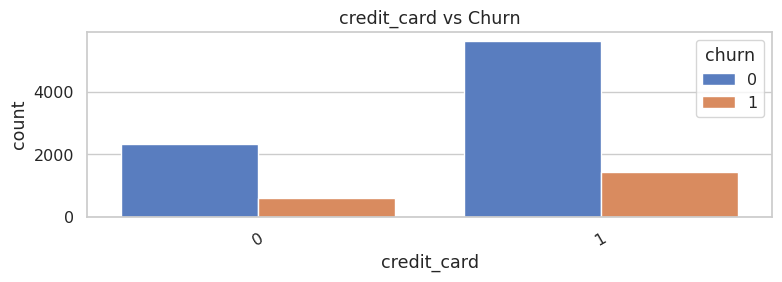

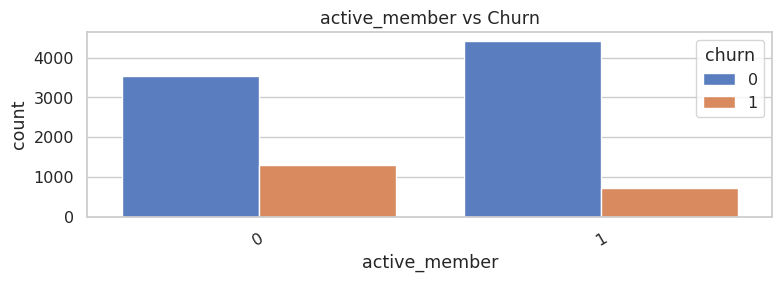

In [10]:
# Catogarical features
cat_cols = ['country', 'gender', 'credit_card','active_member']
for c in cat_cols:
  plt.figure(figsize=(8,3))
  sns.countplot(data=df,x=c,hue='churn')
  plt.title(f'{c} vs Churn')
  plt.xticks(rotation=30)
  plt.tight_layout()
  plt.show()

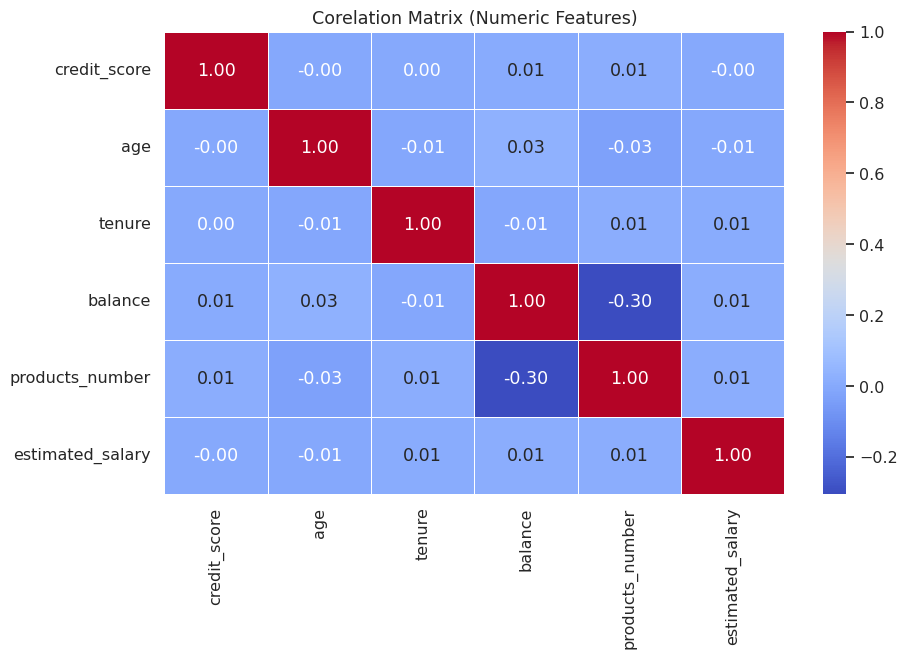

In [11]:
# heatmap visualisation
num_cols =['credit_score', 'age', 'tenure', 'balance', 'products_number','estimated_salary']
corr = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.6)
plt.title('Corelation Matrix (Numeric Features)')
plt.show()

In [12]:
# Neumeric corelation heatmap
neumeric_data= df[num_cols]
corr = neumeric_data.corr()
corr.style.background_gradient(cmap='coolwarm')

,credit_score,age,tenure,balance,products_number,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


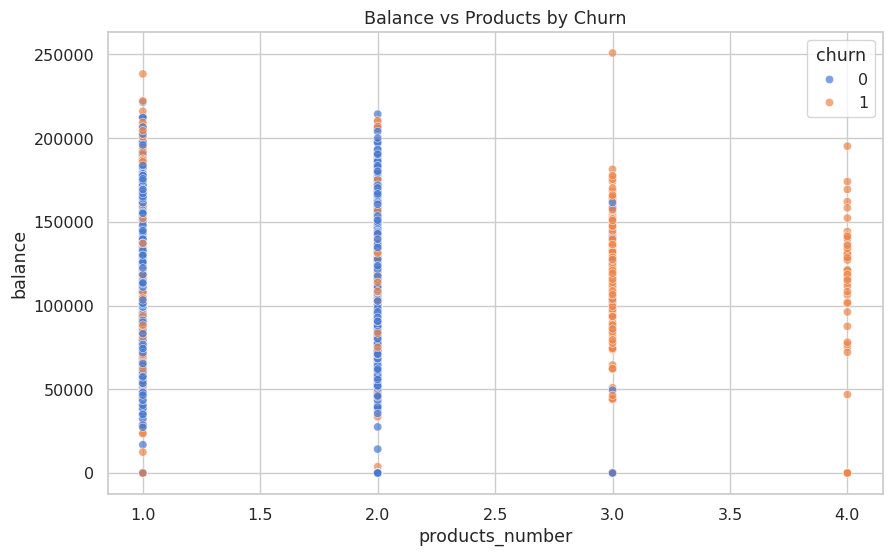

In [13]:
# Balance vs Product scatter
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='products_number', y='balance', hue='churn', alpha=0.7)
plt.title('Balance vs Products by Churn')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

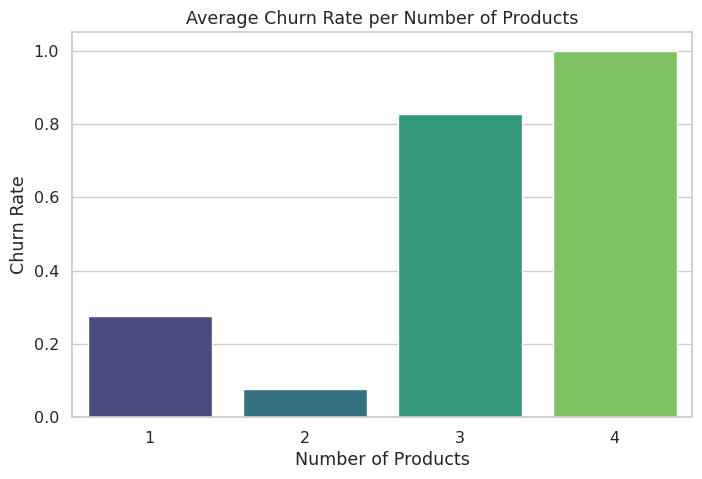

In [14]:
# Average churn rate per number of products
churn_rates = df.groupby('products_number')['churn'].mean().reset_index()

#plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rates, x='products_number',y='churn', palette='viridis')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Average Churn Rate per Number of Products')
plt.show

**Feature Engineering**

In [15]:
df_fe = df.copy()

#balance per product
df_fe['balance_per_product'] = df_fe['balance']/(df_fe['products_number'].replace(0,np.nan))
df_fe['balance_per_product'].fillna(0, inplace=True)

#Salary to balance ratio
df_fe['salary_balance_ratio'] = df_fe['estimated_salary']/df_fe['balance'].replace(0,np.nan)
df_fe['salary_balance_ratio'].replace([np.inf,-np.inf],np.nan, inplace=True)
df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].median(), inplace=True)


#Age group
bins =[0, 25,35, 45, 55, 65, 100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
df_fe['age_group']=pd.cut(df_fe['age'], bins=bins, labels=labels)

#Tenure bucket
df_fe['tenure_bucket'] = (df_fe['balance']>df_fe['balance'].quantile(0.75)).astype(int)

# Quick checks
df_fe[['balance_per_product','salary_balance_ratio','age','age_group','tenure','tenure_bucket']].head()

,balance_per_product,salary_balance_ratio,age,age_group,tenure,tenure_bucket
0,0.000000,0.839258,42,35-44,2,0
1,83807.860000,1.342864,41,35-44,1,0
2,53220.266667,0.713585,42,35-44,8,1
3,0.000000,0.839258,39,35-44,1,0
4,125510.820000,0.630098,43,35-44,2,0


**Preprocessing -encoding & scaling**

In [16]:
#default feature and target
target='churn'
drop_cols=['customer_id']
features = [c for c in df_fe.columns if c not in [target]+ drop_cols]

neumeric_features = ['credit_score', 'age', 'tenure','balance','products_number','estimated_salary',
                     'balance_per_product','salary_balance_ratio']
categorical_features= ['country','gender','credit_card','active_member','age_group','tenure_bucket']
df_fe[categorical_features] = df_fe[categorical_features].astype('object')

neumeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))

])

preprocessor = ColumnTransformer(transformers=[
    ('num', neumeric_transformer, neumeric_features),
    ('cut', categorical_transformer, categorical_features)
])

print('Neumeric features:', neumeric_features)
print('Categorical features:', categorical_features)

Neumeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket']


**Train  Test split**

In [17]:
x=df_fe[features]
y=df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y,random_state=42)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train Churn Prediction: ' , y_train.mean(), '\n Test Churn Proportion: ',y_test.mean())

Train shape: (8000, 14)
Test shape: (2000, 14)
Train Churn Prediction:  0.20375 
 Test Churn Proportion:  0.2035


**Train Multiple models with a pipeline and compare using cross-validation**

In [19]:
models={
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    # 'Naive Bayes': GaussianNB(),
    # 'SVC': SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
  pipe = Pipeline(steps=[('preprocessor',preprocessor), ('classifier', model)])

  scores = cross_val_score(pipe, X_train,y_train, cv=cv, scoring='roc_auc',n_jobs=-1)
  results[name] = scores
  print(f"{name} AUC: Mean={scores.mean():.4f} Std={scores.std():.4f}")

Logistic Regression AUC: Mean=0.7873 Std=0.0246
Random Forest AUC: Mean=0.8491 Std=0.0122
Gradient Boosting AUC: Mean=0.8633 Std=0.0097
AdaBoost AUC: Mean=0.8462 Std=0.0133


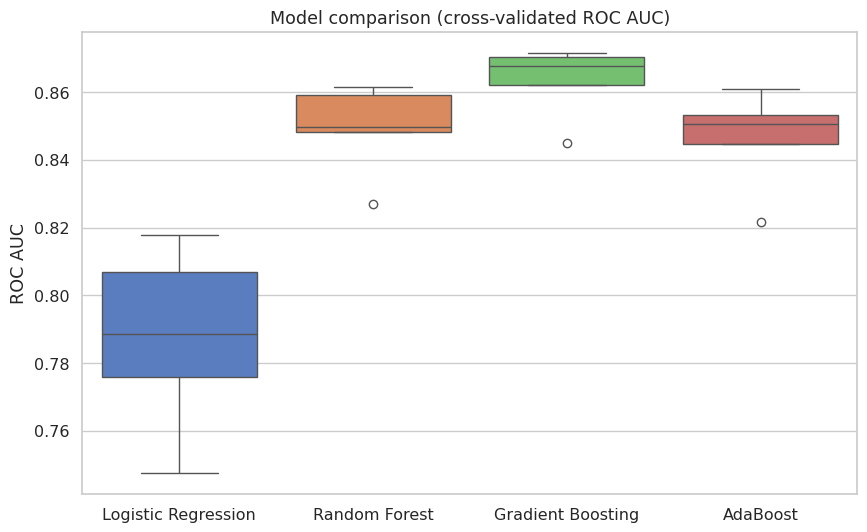

In [20]:
# Boxplot of CV AUC scores
plt.figure(figsize=(10,6))
sns.boxplot(data=[results[m] for m in list(results.keys())])
plt.xticks(ticks=range(len(results)), labels=list(results.keys()))
plt.ylabel("ROC AUC")
plt.title("Model comparison (cross-validated ROC AUC)")
plt.show()

**Fit best model on full train set and evaluate on test set**

In [21]:
best_name= max(results.keys(), key=lambda k:results[k].mean())
best_name, results[best_name].mean()

('Gradient Boosting', np.float64(0.8633062380214002))

Accuracy: 0.8660
Precision: 0.7747
Recall: 0.4816
F1 Score: 0.5939
ROC AUC: 0.8706

 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.48      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



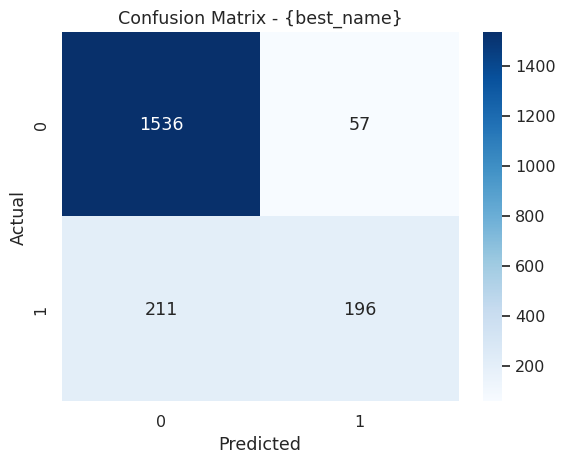

In [22]:
best_model = models[best_name]
best_pipeline=Pipeline(steps=[('preprocessor',preprocessor),
                               ('classifier',best_model)])

best_pipeline.fit(X_train,y_train)

#predictions
y_pred = best_pipeline.predict(X_test)
y_proba= best_pipeline.predict_proba(X_test)[:,1]

#Metrics
acc=accuracy_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc=roc_auc_score(y_test,y_proba)


print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc:.4f}")


print("\n Classification Report:")
print(classification_report(y_test, y_pred))


#confuision matrix
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - {best_name}')
plt.show()

**Feature importance**

,0
age,0.327366
products_number,0.266654
balance,0.059252
balance_per_product,0.058523
active_member_1,0.057540
country_Germany,0.050784
active_member_0,0.043042
salary_balance_ratio,0.028229
estimated_salary,0.028163
credit_score,0.025821


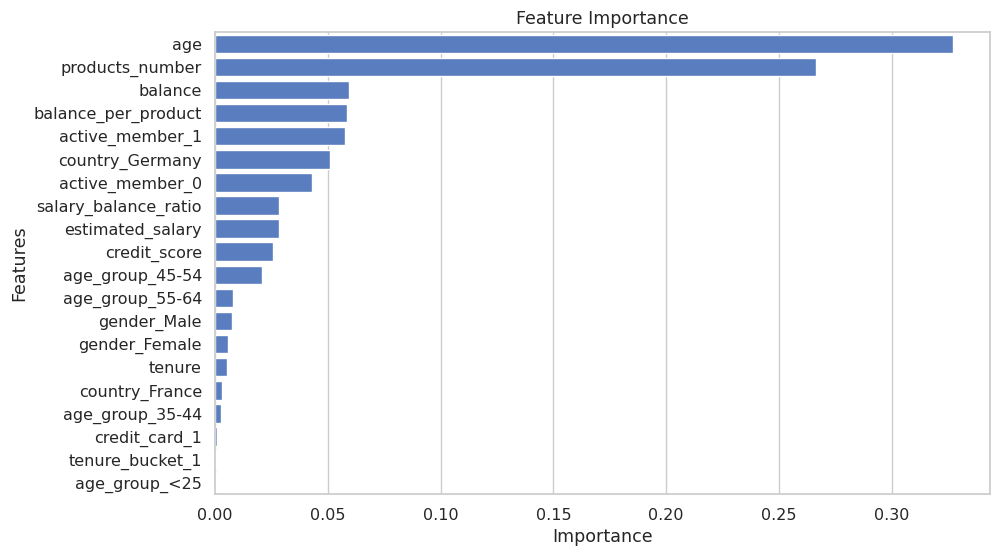

In [24]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
  num_features=neumeric_features
  cat_features=best_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)
  feature_names = num_features + cat_features.tolist()
  importances = best_pipeline.named_steps['classifier'].feature_importances_
  fi = pd.Series(importances, index=feature_names).sort_values(ascending= False)[:20]
  display(fi)
  plt.figure(figsize=(10,6))
  sns.barplot(x=fi, y=fi.index)
  plt.xlabel('Importance')
  plt.ylabel('Features')
  plt.title('Feature Importance')
  plt.show()

**Save the best pipeline and preprocessing artifacts**

In [25]:
joblib.dump(best_pipeline, 'best_churn_pipeline.pkl')
print("Saved pipeline: best_churn_pipeline.pkl")

Saved pipeline: best_churn_pipeline.pkl
